In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance


In [4]:
from imblearn.over_sampling import SMOTE

In [6]:
df = pd.read_csv('/content/Loan_default.csv')
print("Loaded dataset shape:", df.shape)
print("Preview:")
display(df.head())

Loaded dataset shape: (255347, 18)
Preview:


,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [7]:
print("\nColumns in dataset:")
print(list(df.columns))



Columns in dataset:
['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner', 'Default']


In [8]:
col_names = {c.lower(): c for c in df.columns}

def get_column(possible_names):
    for name in possible_names:
        if name.lower() in col_names:
            return col_names[name.lower()]
    return None

In [17]:
col_loan_amount = get_column(['loanamount', 'loan_amount', 'loan amount', 'loanAmt', 'loan'])
col_annual_income = get_column(['annualincome', 'annual_income', 'yearly_income', 'income'])
col_credit_score = get_column(['creditscore', 'credit_score', 'fico', 'fico_score'])
col_monthly_debt = get_column(['monthlydebt', 'monthly_debt', 'monthly_payments', 'total_monthly_debt'])
col_employment_length = get_column(['employmentlength', 'employment_length', 'emp_length', 'years_employed'])
col_home_ownership = get_column(['homeownership', 'home_ownership', 'home_status'])
col_revolving_credit_limit = get_column(['revolvingcreditlimit', 'revolving_credit_limit', 'revolving_limit', 'revolving'])
col_credit_card_debt = get_column(['creditcarddebt', 'credit_card_debt', 'card_debt', 'cc_debt'])
col_target = get_column(['target', 'default', 'is_default', 'loan_status', 'approved', 'approval', 'label'])
col_dtiratio = get_column(['dtiratio', 'dti_ratio', 'dti'])

In [18]:
print("\nAuto-detected columns mapping:")
mapping = {
    'loan_amount': col_loan_amount,
    'annual_income': col_annual_income,
    'credit_score': col_credit_score,
    'dtiratio': col_dtiratio,
    'monthly_debt': col_monthly_debt,
    'employment_length': col_employment_length,
    'home_ownership': col_home_ownership,
    'revolving_credit_limit': col_revolving_credit_limit,
    'credit_card_debt': col_credit_card_debt,
    'target': col_target
}
for k, v in mapping.items():
    print(f"  {k}: {v}")


Auto-detected columns mapping:
  loan_amount: LoanAmount
  annual_income: Income
  credit_score: CreditScore
  dtiratio: DTIRatio
  monthly_debt: None
  employment_length: None
  home_ownership: None
  revolving_credit_limit: None
  credit_card_debt: None
  target: Default


In [19]:
missing = [k for k, v in mapping.items() if v is None]
if missing:
    print("\nWarning: Could not auto-detect columns for:", missing)
    print("Please edit the mapping above to match your dataset column names and re-run.")



Please edit the mapping above to match your dataset column names and re-run.


In [23]:
selected_cols = [v for v in mapping.values() if v is not None]
df_work = df[selected_cols].copy()
df_work.columns = [k for k, v in mapping.items() if v is not None]  # rename to standard names

# Calculate monthly_debt since it wasn't directly available
# This calculation assumes DTIRatio is a decimal ratio (e.g., 0.30 for 30%)
# If DTIRatio in your dataset is a percentage (e.g., 30 for 30%), you might need to adjust:
# df_work['monthly_debt'] = df_work['dtiratio'] / 100 * (df_work['annual_income'] / 12)

if 'dtiratio' in df_work.columns and 'annual_income' in df_work.columns:
    df_work['monthly_debt'] = df_work['dtiratio'] * (df_work['annual_income'] / 12)
    print("Calculated 'monthly_debt' using 'dtiratio' and 'annual_income'.")
else:
    print("Warning: Could not calculate 'monthly_debt' as 'dtiratio' or 'annual_income' are missing from df_work.")

print("\nUpdated working dataframe columns:", df_work.columns.tolist())
display(df_work.head())

Calculated 'monthly_debt' using 'dtiratio' and 'annual_income'.

Updated working dataframe columns: ['loan_amount', 'annual_income', 'credit_score', 'dtiratio', 'target', 'monthly_debt']


,loan_amount,annual_income,credit_score,dtiratio,target,monthly_debt
0,50587,85994,520,0.44,0,3153.113333
1,124440,50432,458,0.68,0,2857.813333
2,129188,84208,451,0.31,1,2175.373333
3,44799,31713,743,0.23,0,607.832500
4,9139,20437,633,0.73,0,1243.250833


In [24]:
numeric_cols = ['loan_amount', 'annual_income', 'credit_score', 'monthly_debt', 'employment_length', 'revolving_credit_limit', 'credit_card_debt']
for col in numeric_cols:
    if col in df_work.columns:
        df_work[col] = pd.to_numeric(df_work[col], errors='coerce')


In [27]:
def add_derived_features(df):
    df = df.copy()
    df['loan_to_income'] = np.where((df['annual_income'] > 0) & (df['loan_amount'].notna()),
                                    df['loan_amount'] / df['annual_income'],
                                    np.nan)
    df['dti_annual'] = np.where((df['annual_income'] > 0) & (df['monthly_debt'].notna()),
                                (df['monthly_debt'] * 12) / df['annual_income'],
                                np.nan)
    # Removed 'credit_utilization' calculation as 'revolving_credit_limit' and 'credit_card_debt' are not available
    df['payment_to_income_monthly'] = np.where((df['annual_income'] > 0) & (df['monthly_debt'].notna()),
                                              df['monthly_debt'] / (df['annual_income'] / 12),
                                              np.nan)
    return df

df_work = add_derived_features(df_work)

In [30]:
print("\nAfter adding derived features:")
display(df_work.head())


After adding derived features:


,loan_amount,annual_income,credit_score,dtiratio,target,monthly_debt,loan_to_income,dti_annual,payment_to_income_monthly
0,50587,85994,520,0.44,0,3153.113333,0.588262,0.44,0.44
1,124440,50432,458,0.68,0,2857.813333,2.467481,0.68,0.68
2,129188,84208,451,0.31,1,2175.373333,1.534154,0.31,0.31
3,44799,31713,743,0.23,0,607.832500,1.412638,0.23,0.23
4,9139,20437,633,0.73,0,1243.250833,0.447179,0.73,0.73


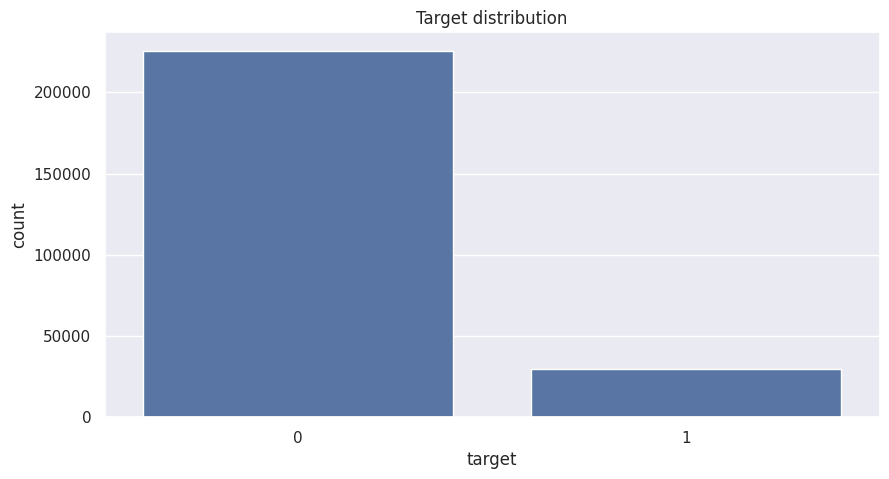

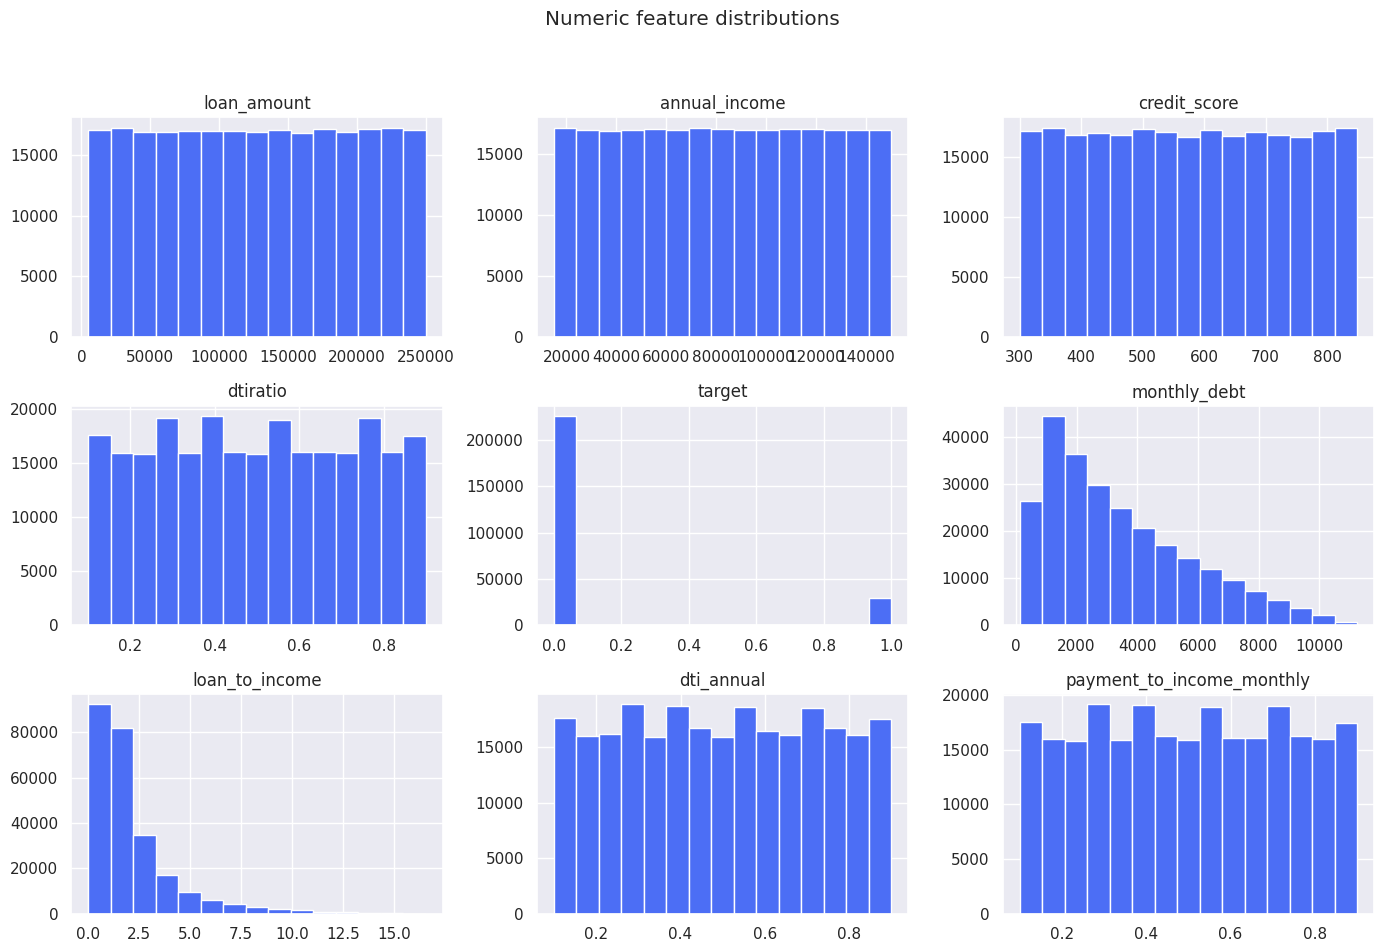

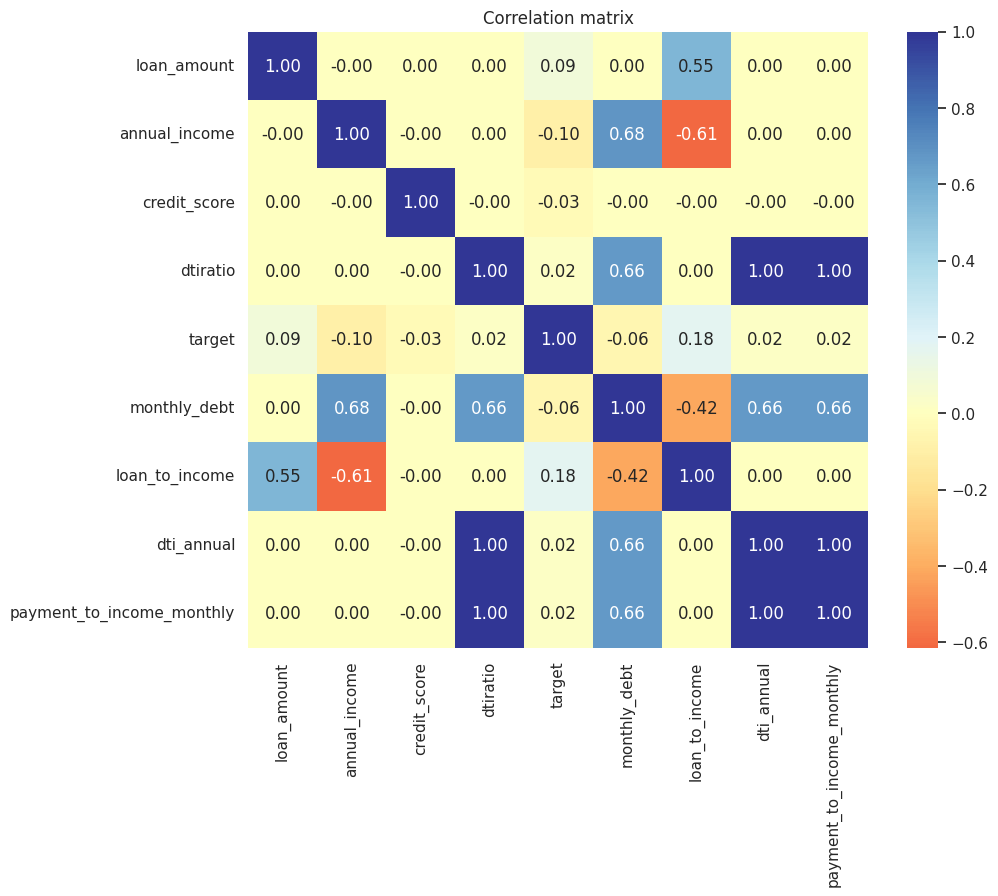

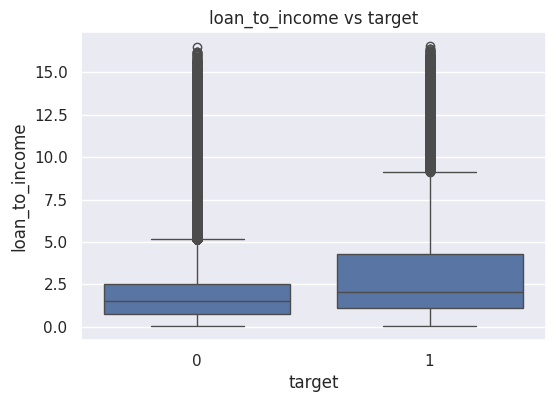

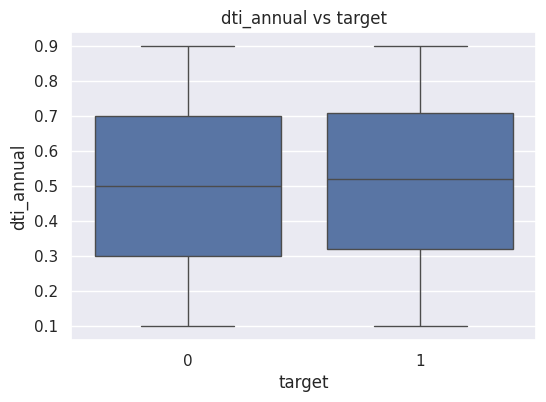

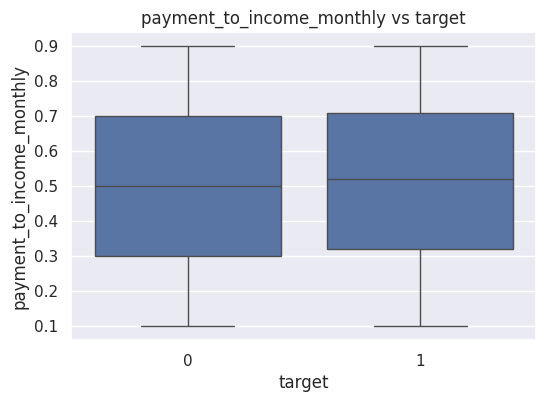

In [31]:
sns.set(style="darkgrid")

def plot_basic_eda(df):
    plt.figure(figsize=(10, 5))
    if 'target' in df.columns:
        sns.countplot(x='target', data=df)
        plt.title('Target distribution')
        plt.show()
    else:
        print("No target column found - skipping target distribution")

    # Numeric histograms
    numeric = df.select_dtypes(include=[np.number]).columns.tolist()
    if numeric:
        df[numeric].hist(bins=15, figsize=(14, 10), layout=(int(np.ceil(len(numeric)/3)), 3), color='#4c6ef5')
        plt.suptitle('Numeric feature distributions')
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

    # Correlation heatmap for numeric features
    plt.figure(figsize=(10, 8))
    corr = df[numeric].corr()
    sns.heatmap(corr, annot=True, fmt=".2f", cmap='RdYlBu', center=0)
    plt.title('Correlation matrix')
    plt.show()

plot_basic_eda(df_work)

# Scatter plots of derived features vs. target if available
if 'target' in df_work.columns:
    for col in ['loan_to_income', 'dti_annual', 'credit_utilization', 'payment_to_income_monthly']:
        if col in df_work.columns:
            plt.figure(figsize=(6, 4))
            sns.boxplot(x='target', y=col, data=df_work)
            plt.title(f'{col} vs target')
            plt.show()

In [32]:
if 'target' in df_work.columns:
    df_model = df_work.dropna(subset=['target']).copy()
else:
    df_model = df_work.copy()

# Simple encoding for home_ownership
if 'home_ownership' in df_model.columns:
    df_model['home_ownership'] = df_model['home_ownership'].astype(str)
else:
    # create a default column if missing
    df_model['home_ownership'] = 'UNKNOWN'

# Choose feature columns (exclude target)
feature_cols = [c for c in df_model.columns if c != 'target']
print("\nSelected features for modeling:", feature_cols)

# Split into X, y if target exists
if 'target' in df_model.columns:
    X = df_model[feature_cols].copy()
    y = df_model['target'].copy()
else:
    X = df_model[feature_cols].copy()
    y = None
    print("\nNo target column found - the script will show preprocessed features but skip supervised training.")


Selected features for modeling: ['loan_amount', 'annual_income', 'credit_score', 'dtiratio', 'monthly_debt', 'loan_to_income', 'dti_annual', 'payment_to_income_monthly', 'home_ownership']


In [33]:
if y is not None:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y if len(np.unique(y))>1 else None)
else:
    X_train = X.copy(); X_test = X.copy(); y_train = None; y_test = None


In [34]:
numeric_features = [c for c in feature_cols if X_train[c].dtype.kind in 'biufc']  # numeric columns
categorical_features = [c for c in feature_cols if c not in numeric_features]


In [35]:
print("\nNumeric features:", numeric_features)
print("Categorical features:", categorical_features)


Numeric features: ['loan_amount', 'annual_income', 'credit_score', 'dtiratio', 'monthly_debt', 'loan_to_income', 'dti_annual', 'payment_to_income_monthly']
Categorical features: ['home_ownership']


In [37]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='UNKNOWN')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

In [38]:
preprocessor.fit(X_train)
X_train_prep = preprocessor.transform(X_train)
X_test_prep = preprocessor.transform(X_test) if y is not None else preprocessor.transform(X_test)

print("\nPreprocessing complete. X_train_prep shape:", X_train_prep.shape)



Preprocessing complete. X_train_prep shape: (204277, 9)


In [39]:
if y is not None:
    print("\nClass distribution in y_train:")
    print(pd.Series(y_train).value_counts())

    # Use SMOTE only if minority class present and numeric
    try:
        sm = SMOTE(random_state=42)
        X_train_bal, y_train_bal = sm.fit_resample(X_train_prep, y_train)
        print("After SMOTE, class distribution:", pd.Series(y_train_bal).value_counts())
    except Exception as e:
        print("SMOTE failed or not appropriate:", e)
        X_train_bal, y_train_bal = X_train_prep, y_train



Class distribution in y_train:
target
0    180555
1     23722
Name: count, dtype: int64
After SMOTE, class distribution: target
0    180555
1    180555
Name: count, dtype: int64



Training LogisticRegression ...
Results for LogisticRegression:
Accuracy: 0.6895829253965146
ROC AUC: 0.6223400149519978


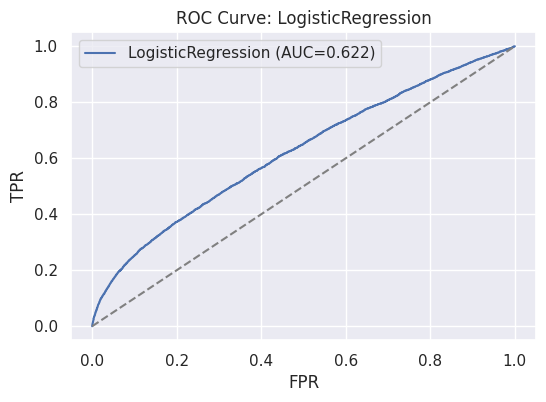


Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.72      0.80     45139
           1       0.17      0.45      0.25      5931

    accuracy                           0.69     51070
   macro avg       0.54      0.59      0.53     51070
weighted avg       0.82      0.69      0.74     51070

Confusion Matrix:


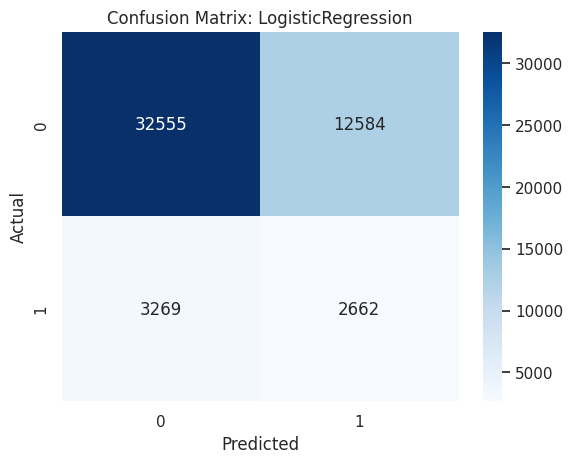


Training RandomForest ...
Results for RandomForest:
Accuracy: 0.8348737027609164
ROC AUC: 0.5784896062578713


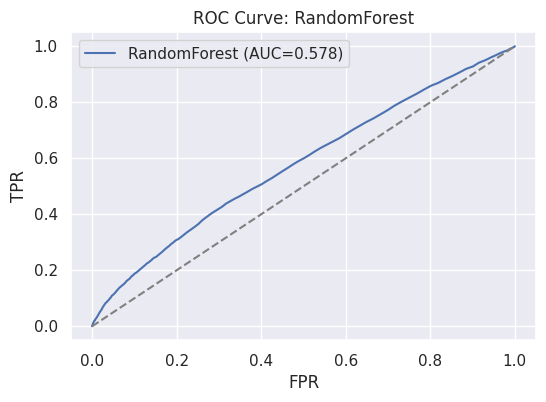


Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.92      0.91     45139
           1       0.21      0.15      0.18      5931

    accuracy                           0.83     51070
   macro avg       0.55      0.54      0.54     51070
weighted avg       0.81      0.83      0.82     51070

Confusion Matrix:


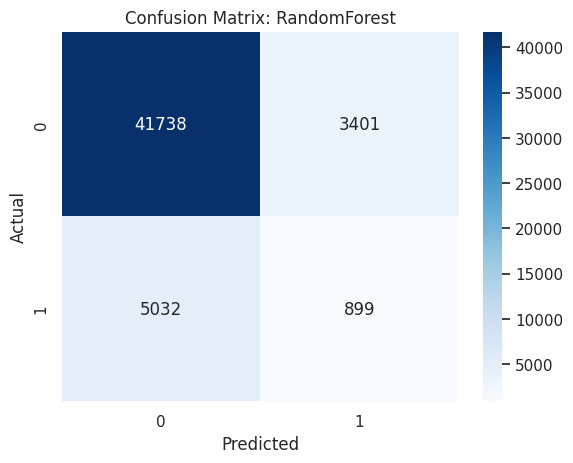

In [41]:
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000),
    'RandomForest': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
}

trained_models = {}
for name, model in models.items():
    print(f"\nTraining {name} ...")
    if y is not None:
        model.fit(X_train_bal, y_train_bal)
        preds = model.predict(X_test_prep)
        proba = model.predict_proba(X_test_prep)[:, 1] if hasattr(model, "predict_proba") else None

        print(f"Results for {name}:")
        print("Accuracy:", accuracy_score(y_test, preds))
        if proba is not None and len(np.unique(y_test)) == 2:
            print("ROC AUC:", roc_auc_score(y_test, proba))
            fpr, tpr, _ = roc_curve(y_test, proba)
            plt.figure(figsize=(6,4))
            plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, proba):.3f})")
            plt.plot([0,1],[0,1],'--', color='gray')
            plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title(f'ROC Curve: {name}'); plt.legend()
            plt.show()

        print("\nClassification Report:")
        print(classification_report(y_test, preds))
        print("Confusion Matrix:")
        cm = confusion_matrix(y_test, preds)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title(f'Confusion Matrix: {name}')
        plt.xlabel('Predicted'); plt.ylabel('Actual')
        plt.show()

        trained_models[name] = model
    else:
        print("No target column; skipping supervised training.")
        break

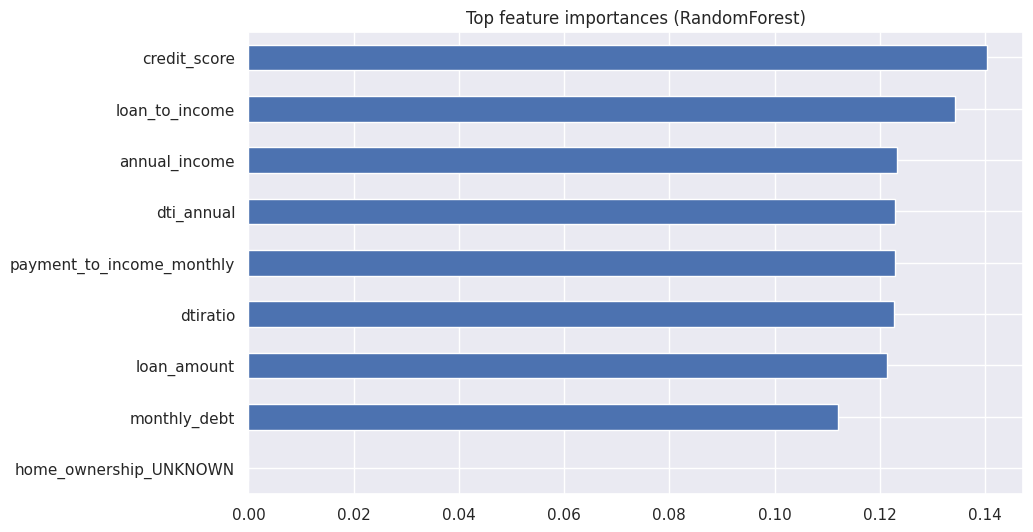

In [42]:
if 'RandomForest' in trained_models:
    rf = trained_models['RandomForest']
    # If one-hot encoding produced many columns we need feature names
    # Build feature names from preprocessor (numeric + onehot categories)
    feature_names = []
    feature_names += numeric_features
    # onehot feature names
    if 'cat' in preprocessor.named_transformers_:
        try:
            ohe = preprocessor.named_transformers_['cat'].named_steps['onehot']
            cat_cols = ohe.get_feature_names_out(categorical_features).tolist()
            feature_names += cat_cols
        except Exception:
            # fallback when no categorical features
            pass

    importances = rf.feature_importances_
    if len(importances) == len(feature_names):
        fi = pd.Series(importances, index=feature_names).sort_values(ascending=False)[:25]
    else:
        # fallback: just show top importances by index
        fi = pd.Series(importances).sort_values(ascending=False)[:25]

    plt.figure(figsize=(10,6))
    fi.plot(kind='barh')
    plt.gca().invert_yaxis()
    plt.title('Top feature importances (RandomForest)')
    plt.show()


In [46]:
print("\nPermutation importance (top 10):")
r = permutation_importance(rf, X_test_prep, y_test, n_repeats=1, random_state=42, n_jobs=1)
perm_imp = pd.Series(r.importances_mean, index=feature_names if len(feature_names)==len(r.importances_mean) else range(len(r.importances_mean)))
display(perm_imp.sort_values(ascending=False).head(10))


Permutation importance (top 10):


,0
dtiratio,0.189955
payment_to_income_monthly,0.181320
dti_annual,0.175700
credit_score,0.001253
home_ownership_UNKNOWN,0.000000
loan_amount,-0.034012
monthly_debt,-0.034658
annual_income,-0.039319
loan_to_income,-0.043254


In [47]:
import joblib
ARTIFACT_DIR = "artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)
joblib.dump(preprocessor, os.path.join(ARTIFACT_DIR, 'preprocessor.joblib'))
if trained_models:
    # save best model (by AUC / accuracy selection logic)
    best_model_name = max(trained_models.keys(), key=lambda k: accuracy_score(y_test, trained_models[k].predict(X_test_prep)))
    joblib.dump(trained_models[best_model_name], os.path.join(ARTIFACT_DIR, f'{best_model_name}.joblib'))
    print(f"\nSaved preprocessor and model: {best_model_name} to {ARTIFACT_DIR}/")

print("\nPipeline complete. Inspect figures above and tune models as needed.")



Saved preprocessor and model: RandomForest to artifacts/

Pipeline complete. Inspect figures above and tune models as needed.
